## HSIC lasso for node pruning

### Date: 05.11.2024

Summary of steps:

1- take X_t and y_t as the outcome of neurons and outputs

2- Apply the HSIC_lasso and Identify the list of potential nodes for pruning, e.g., nodes with Zero coefficient

3- Report the RMSE error for the applied pruning




### To run under the given previous virtual env the following lib should be installed:
#### pip install pyHSICLassop

In [22]:
# pip install hyperopt jupyter matplotlib pandas requests reservoirpy scikit-learn seaborn brevitas fxpmath

In [23]:
# pip install pyHSICLasso

In [24]:
import numpy as np
from reservoirpy.observables import rmse, rsquare,nrmse
from sklearn.metrics import mean_absolute_error


Reservoir Size 250: RMSE=0.0014, R^2=1.0000, MSE=0.0000, NRMSE=0.0007

Summary of Results:
N=250 | RMSE=0.0014 | R^2=1.0000 | MSE=0.0000 | NRMSE=0.0007


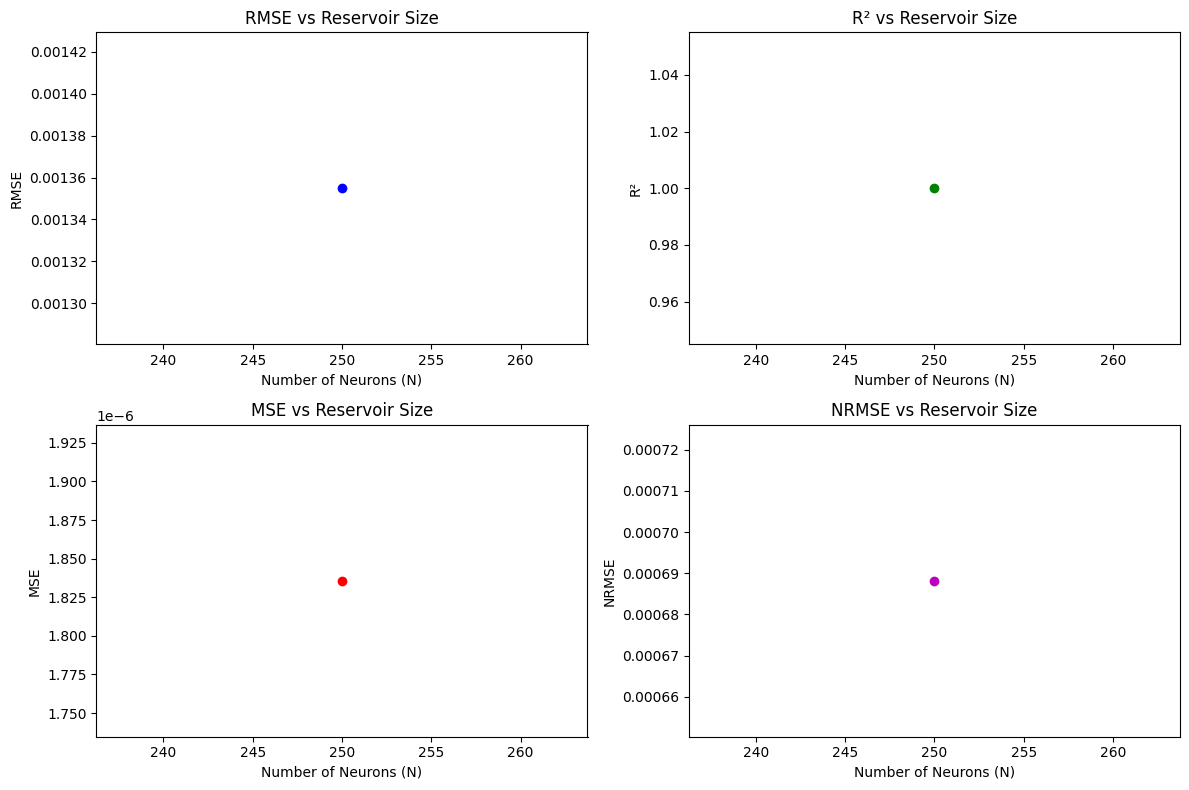

In [25]:
import numpy as np
import torch
from reservoirpy.datasets import lorenz
from reservoirpy.nodes import Reservoir, Ridge
import matplotlib.pyplot as plt
import reservoirpy as rpy
from reservoirpy.observables import rmse, rsquare, mse, nrmse

# Set seed for reproducibility
rpy.set_seed(42)

# Parameters for NARMA10 task


rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!
X = lorenz(10000)
X = 2 * (X - X.min()) / (X.max() - X.min()) - 1

train_len = 5000
forecast = 1

X_train = X[:train_len]
Y_train = X[forecast : train_len + forecast]

X_test = X[train_len : -forecast]
Y_test = X[train_len + forecast:]
# Experiment with different reservoir sizes (units)
reservoir_sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]  # Increase the reservoir size incrementally
reservoir_sizes = [250]
# Performance tracking
results = []

# Loop through different reservoir sizes to find the best
for N in reservoir_sizes:
    # Reservoir and readout configurations
    reservoir = Reservoir(
        units=N,  # Use 'units' instead of 'N' for number of neurons
        lr=0.65,          # Leaking rate: Small to ensure enough memory
        sr=0.4,         # Spectral radius close to 1 for stable dynamics
        input_connectivity=0.34,  # High input-to-reservoir connectivity
        rc_connectivity=0.1,     # Low internal connectivity for simplicity
        input_scaling=1        # Input scaling to help with learning
    )
    
    # Ridge regularization for the readout
    readout = Ridge(ridge=1e-1)  # Ridge regularization
    # readout.ridge=1e-4
    # Combine reservoir and readout to form the ESN model
    esn_model = reservoir >> readout

    # Fit the model (with warmup period)
    esn_model = esn_model.fit(X_train, Y_train, warmup=400)

    # Run the model to predict outputs
    # Y_pred = esn_model.run(X_test)
    reservoir_states_test = reservoir.run(X_test)  # Shape: (time_steps, num_neurons).
    reservoir_states_test.shape
    np.save('reservoir_states_test', reservoir_states_test)
    output_test = readout.run(reservoir_states_test)  # Shape: (time_steps, output_dim)
    output_test.shape
    np.save('output_test', output_test)
    # Calculate performance metrics
    rmse_val = rmse(Y_test, output_test)
    r2_score = rsquare(Y_test, output_test)
    mse_val = mse(Y_test, output_test)
    nrmse_val = nrmse(Y_test, output_test)  # Fix for proper NRMSE calculation

    # Save results for comparison
    results.append({
        "N": N,
        "RMSE": rmse_val,
        "R^2": r2_score,
        "MSE": mse_val,
        "NRMSE": nrmse_val
    })
    print(f"Reservoir Size {N}: RMSE={rmse_val:.4f}, R^2={r2_score:.4f}, MSE={mse_val:.4f}, NRMSE={nrmse_val:.4f}")

# Print out the results for all reservoir sizes
print("\nSummary of Results:")
for result in results:
    print(f"N={result['N']} | RMSE={result['RMSE']:.4f} | R^2={result['R^2']:.4f} | MSE={result['MSE']:.4f} | NRMSE={result['NRMSE']:.4f}")

# Plot results to visualize how reservoir size impacts performance
sizes = [result['N'] for result in results]
rmse_vals = [result['RMSE'] for result in results]
r2_vals = [result['R^2'] for result in results]
mse_vals = [result['MSE'] for result in results]
nrmse_vals = [result['NRMSE'] for result in results]

# Plot RMSE, R², MSE, and NRMSE vs Reservoir Size
plt.figure(figsize=(12, 8))

# RMSE Plot
plt.subplot(2, 2, 1)
plt.plot(sizes, rmse_vals, marker='o', color='b')
plt.title('RMSE vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('RMSE')

# R² Plot
plt.subplot(2, 2, 2)
plt.plot(sizes, r2_vals, marker='o', color='g')
plt.title('R² vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('R²')

# MSE Plot
plt.subplot(2, 2, 3)
plt.plot(sizes, mse_vals, marker='o', color='r')
plt.title('MSE vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('MSE')

# NRMSE Plot
plt.subplot(2, 2, 4)
plt.plot(sizes, nrmse_vals, marker='o', color='m')
plt.title('NRMSE vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('NRMSE')

plt.tight_layout()
plt.show()



In [26]:
# N=250
# from reservoirpy.datasets import lorenz
# from reservoirpy.nodes import Reservoir, Ridge
# import matplotlib.pyplot as plt
# import reservoirpy as rpy

# rpy.verbosity(0)  # no need to be too verbose here
# rpy.set_seed(42)  # make everything reproducible!
# X = lorenz(10000)
# X = 2 * (X - X.min()) / (X.max() - X.min()) - 1
# # create fxp variable with value 7.25

# #reservoir = Reservoir(units=400, lr=0.1, sr=1.25)

# #reservoir = Reservoir(10, lr=1, sr=1.25, input_connectivity=0.90,rc_connectivity=0.1,input_scaling=0.001)
# reservoir = Reservoir(N, lr=0.3, sr=1, input_connectivity=0.9,rc_connectivity=0.2,input_scaling=0.5)

# readout = Ridge(ridge=1e-8)
# esn_model = reservoir >> readout
# # esn_model=esn_model.fit(X[:5000], X[1:5001], warmup=100)


# plt.figure(figsize=(10, 3))
# plt.title("Macky_Glassy.")
# plt.ylabel("$F(t)$")
# plt.xlabel("$t$")
# plt.plot(X)
# plt.show()

In [27]:
# train_len = 5000
# forecast = 1

# X_train = X[:train_len]
# Y_train = X[forecast : train_len + forecast]

# X_test = X[train_len : -forecast]
# Y_test = X[train_len + forecast:]
# esn_model = esn_model.fit(X_train, Y_train, warmup=1000

# )
#  #states of each time stamp over test set
# reservoir_states_test = reservoir.run(X_test)  # Shape: (time_steps, num_neurons).
# reservoir_states_test.shape
# np.save('reservoir_states_test', reservoir_states_test)
# output_test = readout.run(reservoir_states_test)  # Shape: (time_steps, output_dim)
# output_test.shape
# np.save('output_test', output_test)
# plt.figure(figsize=(15, 3))
# plt.title("A sine wave and its future.")
# plt.xlabel("$t$")
# plt.plot(output_test, label="Predicted sin(t+1)", color="blue")
# plt.plot(Y_test.astype(float), label="Real sin(t+1)", color="red")
# plt.legend()
# plt.show()
# print("RMSE:", rmse(output_test, Y_test), "R^2 score:", rsquare(output_test, Y_test))
# mae = mean_absolute_error(output_test, Y_test)
# print(f"Mean Absolute Error (MAE): {mae}")

In [28]:
# print(type(reservoir_states_test))
# output_test.shape
# print(type(reservoir_states_test))
# print(reservoir_states_test[:,0].shape)

Input int quantized:
 [[ -34  -34  -34]
 [ -34  -32  -34]
 [ -33  -28  -34]
 ...
 [ -80 -101   44]
 [ -86 -102   62]
 [ -89  -95   80]] 

Input scale: 0.0078125
Input zero_point: 0.0
Extract quantized integer Win and Scale and Zero_point
Input int quantized:
 [[-128    0 -128]
 [   0    0    0]
 [   0    0    0]
 [   0  127    0]
 [   0    0    0]
 [   0    0    0]
 [-128    0    0]
 [ 127    0 -128]
 [ 127 -128    0]
 [   0    0    0]
 [-128 -128  127]
 [ 127 -128    0]
 [   0 -128    0]
 [-128    0    0]
 [-128    0    0]
 [   0  127    0]
 [ 127    0 -128]
 [ 127  127 -128]
 [   0 -128  127]
 [ 127    0  127]
 [   0    0    0]
 [-128    0  127]
 [-128    0    0]
 [   0    0    0]
 [   0    0    0]
 [   0  127    0]
 [   0 -128 -128]
 [   0    0    0]
 [   0    0 -128]
 [   0    0 -128]
 [   0  127    0]
 [ 127  127 -128]
 [   0    0 -128]
 [-128  127    0]
 [   0    0    0]
 [ 127    0  127]
 [   0  127    0]
 [   0 -128    0]
 [   0    0  127]
 [ 127    0    0]
 [   0    0 -128]
 [

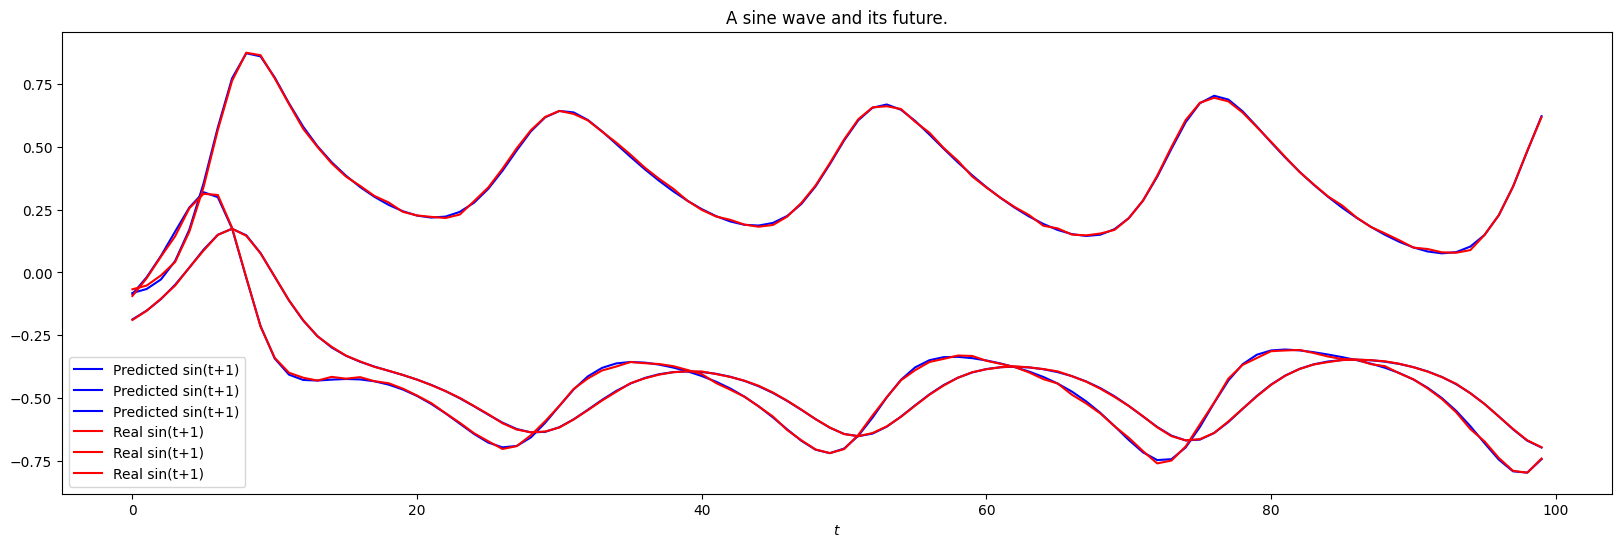

RMSE Quantized: 0.0019307659328166664 R^2 score: 0.9999775062458276
MAPE1 0.816177195231093


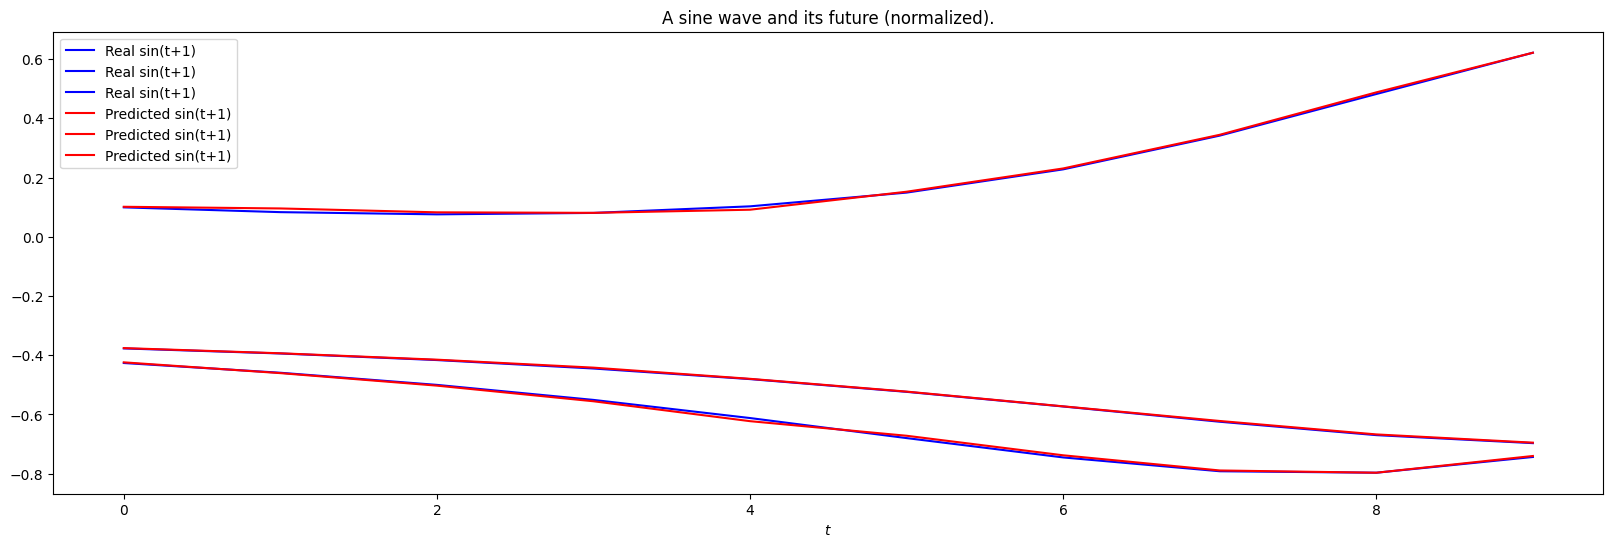

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from brevitas.nn import QuantHardTanh, QuantIdentity, QuantLinear
from brevitas.quant import Int8ActPerTensorFloat, Int8WeightPerTensorFloat
from reservoirpy.datasets import mackey_glass
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import rmse, rsquare
from reservoirpy import Node
import reservoirpy as rpy
rpy.verbosity(0)
rpy.set_seed(42)
# pruned_res_size = len(ind)

# # Parameters
# N = pruned_res_size #reservoir size
bit_width = 8 # quantization bit width
#integer, out , scale,  quantizer, layer , ...
# input

from brevitas.nn import QuantIdentity
import math
def extract_Qinput(input, num_bits=8):
  quant_identity = QuantIdentity(return_quant_tensor=True,bit_width=num_bits)
  float_input = torch.tensor(input,dtype=torch.float64)
  quant_input = quant_identity(float_input)
  out = quant_input.int().detach().numpy()

  scale = quant_input.scale.detach().numpy()
  zero_point = quant_input.zero_point.numpy()
  print(f"Input int quantized:\n {out} \n")
  print(f"Input scale: {scale}")
  print(f"Input zero_point: {zero_point}")
  return out, scale, zero_point
from brevitas.nn import QuantLinear
from brevitas.quant import Int8ActPerTensorFloat,Int8WeightPerTensorFloat
import math


def quantize_output_layer(weights, num_bits=8):
  quant_linear = QuantLinear(2, 4,weight_bit_width=num_bits, weight_quant=Int8WeightPerTensorFloat, requires_grad=False)
  quant_linear.weight.data = torch.tensor(weights,dtype=torch.float64)

  out = quant_linear.quant_weight().int().detach().numpy()
  scale = quant_linear.quant_weight().scale.detach().numpy()
  # out = quant_linear.quant_weight().value.data.numpy()


  #out = out * 0

  return out,scale

int_x,x_scale,x_zero_point = extract_Qinput(X,num_bits=bit_width)
np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
print('Extract quantized integer Win and Scale and Zero_point')
int_Win,scale_Win,zero_point_Win = extract_Qinput(esn_model.nodes[0].Win.todense(),num_bits=bit_width)
print('Extract quantized integer Wr and Scale and Zero_point')
int_Wr,scale_Wr,zero_point_Wr = extract_Qinput(esn_model.nodes[0].W.todense(),num_bits=bit_width)
int_bias, scale_bias, zero_point_bias = extract_Qinput(esn_model.nodes[0].bias.todense(), num_bits=bit_width)


input_scale = (scale_Win * x_scale)
threshold_scale = 0.0078125
reservoir_scale = (scale_Wr * threshold_scale)

def compute_integer_thresholds(scale):

    a = -1  # Lower bound of Hard Tanh
    b = 1   # Upper bound of Hard Tanh
    a_scaled = np.int32(a / scale)
    b_scaled = np.int32(b / scale)
    return a_scaled, b_scaled

def piecewise_linear_hard_tanh_integer(x, a_scaled, b_scaled):

    # Apply saturation logic
    x = np.where(x < a_scaled, a_scaled, x)
    x = np.where(x > b_scaled, b_scaled, x)
    x=x + b_scaled
    return (x / 256).astype(np.int32)

a_scaled, b_scaled = compute_integer_thresholds(input_scale)
c_scaled, d_scaled = compute_integer_thresholds(reservoir_scale)

def forward2(node: Node, x: np.ndarray) -> np.ndarray:
    state = node.state()  # get current node state  # Current reservoir state as integer
    state_int = state.astype(np.int64)
    W_res = node.Wr
    W_in = node.Win
    bias_res = node.Bias
    state_int = state_int.reshape(1,N)

    r = state_int @ W_res.astype(np.int32)
    s = x @ W_in.astype(np.int32).T
    s = s.reshape(1,N)
    # Precompute thresholds and scale
    # a_scaled, b_scaled = compute_integer_thresholds(scale_Wr)
    bias_res = bias_res.reshape(1, N)



    # Apply integer PLA to reservoir and input contributions
    out_r = piecewise_linear_hard_tanh_integer(s,a_scaled, b_scaled)
    out_s = piecewise_linear_hard_tanh_integer(r,c_scaled, d_scaled)

    return out_r + out_s 

def initialize(node: Node, x: np.ndarray = None, y: np.ndarray = None):
    """This function receives a data point x at runtime and uses it to
    infer input and output dimensions.
    """
    if x is not None:
        node.set_input_dim(x.shape[1])
        node.set_output_dim(N)
        node.set_param("Wr", int_Wr)
        node.set_param("Win", int_Win)
        node.set_param("Bias", int_bias)

class CustomNode(Node):
    def __init__(self, const2=-1, name=None):
        super().__init__(
            forward=forward2,
            initializer=initialize,

            params={"const1": None, "Wr":None, "Win":None, "Bias":None},
            hypers={"const2": const2},
            name=name,
        )

node = CustomNode(const2=-1, name="custom_node3")
# node.ridge = 1e-5
# readout = Ridge(ridge=1e-5)
esn_model_PTQ = node >> readout

Quantized_States = node.run(int_x[:5000].astype(np.float64))

Quantized_States = Quantized_States * threshold_scale
readout.fit(Quantized_States.astype(np.float64), X[1:5001].astype(np.float64), warmup=1000)
# esn_model_PTQ = node >> readout_pruned

# esn_model_PTQ = esn_model_PTQ.fit(int_x[:5000].astype(np.float64), int_x[1:5001].astype(np.float64), warmup=1000)

Quantized_States = node.run(int_x[5001:-1].astype(np.float64))
Quantized_States = Quantized_States * threshold_scale

Y_pred_PTQ_origin = readout.run(Quantized_States.astype(np.float64))



min_pred = np.min(Y_pred_PTQ_origin)
max_pred = np.max(Y_pred_PTQ_origin)
Y_pred_PTQ_normalized = 2 * (Y_pred_PTQ_origin - min_pred) / (max_pred - min_pred) - 1

# Wout_quantized, scale_out = quantize_output_layer(readout.Wout,num_bits=bit_width)
# readout.Wout = Wout_quantized

# a=threshold_scale * scale_out

# Y_pred_PTQ = esn_model_PTQ.run(int_x[5001:-1])
# Y_pred_PTQ = Y_pred_PTQ *a

from reservoirpy.observables import rmse, rsquare

print("RMSE Quantized:", rmse(X[5002:], Y_pred_PTQ_origin), "R^2 score:", rsquare(X[5002:], Y_pred_PTQ_origin))

plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future.")
plt.xlabel("$t$")
plt.plot(X[-100:], label="Predicted sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ_origin[-100:], label="Real sin(t+1)", color="red")
plt.legend()
plt.show()

min_x = np.min(X[-10:])
max_x = np.max(X[-10:])
min_pred = np.min(Y_pred_PTQ_origin[-10:])
max_pred = np.max(Y_pred_PTQ_origin[-10:])

Y_pred_PTQ_origin_normalized = (Y_pred_PTQ_origin[-10:] - min_pred) / (max_pred - min_pred) * (max_x - min_x) + min_x

print("RMSE Quantized:", rmse(Y_pred_PTQ_origin[-10:], Y_pred_PTQ_origin_normalized), "R^2 score:", rsquare(Y_pred_PTQ_origin[-10:], Y_pred_PTQ_origin_normalized))
MAPE1= np.mean(np.abs((Y_pred_PTQ_origin[-10:] - Y_pred_PTQ_origin_normalized) / Y_pred_PTQ_origin[-10:])) * 100  
print("MAPE1",MAPE1)
plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future (normalized).")
plt.xlabel("$t$")
plt.plot(X[-10:], label="Real sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ_origin_normalized, label="Predicted sin(t+1)", color="red")
plt.legend()
plt.show()

In [30]:
from reservoirpy.nodes import Reservoir
import reservoirpy as rpy

rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!

def create_new_reservoir(model, pruned_W, pruned_W_in, pruned_bias):


    # Create a new reservoir with the pruned configuration
    pruned_reservoir = Reservoir(
        len(pruned_bias.todense()),
        lr=model.nodes[0].lr,
        sr=model.nodes[0].sr,
        input_connectivity=model.nodes[0].input_connectivity,
        # rc_connectivity=model.nodes[0].rc_connectivity,
        input_scaling=(model.nodes[0].input_scaling),
        input_dim=model.nodes[0].input_dim,
        # seed=42
    )

    # Assign the pruned weights to the new reservoir
    pruned_reservoir.W = pruned_W
    pruned_reservoir.Win = pruned_W_in
    # pruned_reservoir.bias = pruned_bias

    return pruned_reservoir

In [31]:
# ///////////////////////////////////////HSIC_Lasso\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
def HSIC_Prune():
    import numpy as np
    from pyHSICLasso import HSICLasso
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    n,o, d = 4999,3,N # n samples, d features
    np.random.seed(0)
    M = reservoir_states_test # Input matrix -> here should be the outcome of neurons
    y = Y_test[:, 0].reshape(-1, 1) # Output of the ESN network
        # Normalize the input data
    scaler = StandardScaler()
    M = scaler.fit_transform(M)
    M_train, M_test, y_train, y_test = train_test_split(M, y, test_size=0.5, random_state=42)

    # Iterate over the number of features
    best_features = None
    best_rmse_diff = float(0.5)  # Difference between current RMSE and target RMSE
    int_list_temp=[]
    for num_features in range(1, d):
        print(num_features)
        hsic_lasso = HSICLasso()

        # Run HSIC Lasso to select a specific number of features
        hsic_lasso.input(M_train, y_train.reshape(-1))
        hsic_lasso.regression(num_feat=num_features)
        # hsic_lasso.plot()
        hsic_lasso.dump()

        selected_indices = hsic_lasso.get_features()
        selected_indices_temp = set(map(int, selected_indices))
        for i in range(len(selected_indices)):
            selected_indices_temp.update(hsic_lasso.get_index_neighbors(feat_index=i,num_neighbors=5))
            # selected_indices.append(hsic_lasso.get_index_neighbors(feat_index=i,num_neighbors=5))
        selected_indices = sorted(list(selected_indices_temp))
        if not selected_indices:  # Skip iteration if no features were selected
            continue
        # print(f"selected_indices: {selected_indices}")
        model = LinearRegression()
        int_list = list(map(int, selected_indices))
        if (int_list==int_list_temp):
            break
        print(f"int_list: {int_list}")
        ind = [x - 1 for x in int_list]
        print(f"ind: {ind}")
        int_list_temp=int_list
        model.fit(M_train[:, ind], y_train.reshape(-1))

        # Calculate RMSE on the test set
        y_pred = model.predict(M_test[:, ind])
        rmse_hsic = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"Found features with num_features={num_features}, RMSE={rmse_hsic} within tolerance of target RMSE.")
    new_size = len(ind)
    print("New reservoir size",len(ind))
    prune_count = new_size

    keep_neurons = ind
    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons,:]

    reservoir_pruned = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)

    readout_pruned = Ridge(ridge=readout.ridge)
    # readout_pruned.bias=readout.bias
    esn_model_pruned = reservoir_pruned >> readout_pruned

    readout_pruned.Wout=pruned_W_out
    readout_pruned.bias = readout.bias
    esn_model_pruned=esn_model_pruned.fit(X_train, Y_train, warmup=400)
    Y_pred_pruned = esn_model_pruned.run(X_test)

    reservoir_pruned.W = pruned_W
    reservoir_pruned.Win = pruned_W_in
    reservoir_pruned.bias = pruned_bias
    esn_model_pruned=esn_model_pruned.fit(X_train, Y_train, warmup=400)
    Y_pred_pruned = esn_model_pruned.run(X_test)

    # Main ERROR
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library

    # Calculate the mean squared error using mean_squared_error from sklearn.metrics
    mse = mean_squared_error(Y_pred_pruned, Y_test)

    # Raise the mean squared error to the power of 0.5
    rmse_pruned = (mse)**(1/2)
    # Print the RMSE
    print (reservoir_pruned.params)
    print(reservoir_pruned.units)

    print("The calculated Root Mean Square Error (RMSE) Pruned HSIC-Lasso is: " + str(rmse_pruned))

    print("R^2 score:", rsquare(Y_pred_pruned, Y_test))
    return rmse_pruned,prune_count,num_features

In [32]:
# ///////////////////////////////////////////////////Spearman////////////////////////////////////////////
# /////////////////////////////////////////////
# Calculate Spearman correlation between each neuron's state and the output
# prune_percentage_spearman=0.5
from scipy.stats import spearmanr
def spearman_Prune(prune_count,num_features):

    correlations = []
    for neuron_index in range(states.shape[1]):
    # Compute Spearman correlation between this neuron's state and the output
        corr, _ = spearmanr(states[:num_features, neuron_index], Y_pred[:num_features, 0])  # Assuming single output dim
        correlations.append(corr)

    # Convert list to numpy array for sorting
    correlations = np.array(correlations)
    correlations[np.isnan(correlations)] = 0

    # Calculate the number of neurons to prune
    num_neurons = len(correlations)

    # Find indices of neurons with lowest correlations
    prune_indices = np.argsort(correlations)[:prune_count]
    keep_neurons = np.setdiff1d(np.arange(N), prune_indices)

    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons,:]



    reservoir_pruned_spearman = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)

    readout_pruned_spearman = Ridge(ridge=readout.ridge)
    # readout_pruned.bias=readout.bias
    esn_model_pruned_spearman = reservoir_pruned_spearman >> readout_pruned_spearman

    readout_pruned_spearman.Wout=pruned_W_out
    # readout_pruned.bias = readout.bias
    esn_model_pruned_spearman=esn_model_pruned_spearman.fit(X_train, Y_train, warmup=1000)
    Y_pred_pruned_spearman = esn_model_pruned_spearman.run(X_test)

    reservoir_pruned_spearman.W = pruned_W
    reservoir_pruned_spearman.Win = pruned_W_in
    # reservoir_pruned.bias = pruned_bias
    esn_model_pruned_spearman=esn_model_pruned_spearman.fit(X_train, Y_train, warmup=1000)
    Y_pred_pruned_spearman = esn_model_pruned_spearman.run(X_test)

    # Main ERROR
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library

    # Calculate the mean squared error using mean_squared_error from sklearn.metrics
    mse = mean_squared_error(Y_pred_pruned_spearman, Y_test)

    # Raise the mean squared error to the power of 0.5
    rmse_pruned_spearman = (mse)**(1/2)
    # Print the RMSE
    print(reservoir_pruned_spearman.units)

    print("The calculated Root Mean Square Error (RMSE) Pruned Spearman is: " + str(rmse_pruned_spearman))

    return rmse_pruned_spearman

In [33]:
# ///////////////////////////////////////////////////PCA////////////////////////////////////////////
# /////////////////////////////////////////////

def PCA_Prune(prune_count,num_features):

    prune_percentage_pca = 0.5  # Match your Spearman pruning percentage

    from sklearn.decomposition import PCA
    # from sklearn.preprocessing import StandardScaler


    # Standardize the reservoir states
    # scaler = StandardScaler()
    # scaled_states = scaler.fit_transform(states)

    # 1. Fit PCA to reservoir states
    pca = PCA(n_components=None)
    pca.fit(states[:num_features,:])  # states shape: (num_samples, num_neurons)

    # 2. Calculate neuron importance scores
    loadings = pca.components_.T  # Shape: (num_neurons, num_components)
    importance_scores = (np.abs(loadings)).sum(axis=1)
    print(importance_scores)
    # 3. Identify neurons to prune (same structure as Spearman)
    # prune_count = int(prune_percentage_pca * N)
    prune_indices = np.argsort(importance_scores)[N-prune_count:]
    keep_neurons = np.setdiff1d(np.arange(N), prune_indices)
    # 4. Prune network matrices (identical to Spearman implementation)
    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons, :]

    # 5. Create new model & evaluate (same structure)
    reservoir_pruned_pca = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)
    readout_pruned_pca = Ridge(ridge=readout.ridge)
    readout_pruned_pca.Wout = pruned_W_out

    esn_model_pruned_pca = reservoir_pruned_pca >> readout_pruned_pca
    esn_model_pruned_pca = esn_model_pruned_pca.fit(X_train, Y_train, warmup=100)
    Y_pred_pruned_pca = esn_model_pruned_pca.run(X_test)

    reservoir_pruned_pca.W = pruned_W
    reservoir_pruned_pca.Win = pruned_W_in
    # reservoir_pruned.bias = pruned_bias
    esn_model_pruned_pca = esn_model_pruned_pca.fit(X_train, Y_train, warmup=1000)
    Y_pred_pruned_pca = esn_model_pruned_pca.run(X_test)
    # Calculate RMSE
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library
    
    mse_pca = mean_squared_error(Y_pred_pruned_pca, Y_test)
    rmse_pruned_pca = math.sqrt(mse_pca)
    print(reservoir_pruned_pca.units)

    print(f"RMSE Pruned PCA: {rmse_pruned_pca}")

    return rmse_pruned_pca

In [34]:
# ///////////////////////////////////////////////////Lasso////////////////////////////////////////////
from sklearn.linear_model import Lasso
import numpy as np
from sklearn.metrics import mean_squared_error

def lasso_Prune(prune_count,num_features):

    # Define Lasso regularization strength (tune this)
    lasso_alpha = 0.1  # Adjust based on dataset size

    # Train Lasso on reservoir states and output
    lasso = Lasso(alpha=lasso_alpha)
    lasso.fit(states[:num_features,:], Y_pred[:num_features, 0])  # Reservoir states as input, actual output as target

    # Get absolute importance of neurons from Lasso coefficients
    neuron_importance = np.abs(lasso.coef_)

    # Determine neurons to prune (those with near-zero weights)
    prune_percentage_lasso = 0.5
    # prune_count = int(prune_percentage_lasso * states.shape[1])
    prune_indices = np.argsort(neuron_importance)[:prune_count]  # Neurons with lowest importance
    keep_neurons = np.setdiff1d(np.arange(states.shape[1]), prune_indices)

    # Prune the reservoir matrices
    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons, :]

    # Create pruned reservoir
    reservoir_pruned_lasso = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)

    readout_pruned_lasso = Ridge(ridge=readout.ridge)
    esn_model_pruned_lasso = reservoir_pruned_lasso >> readout_pruned_lasso

    # Assign pruned output weights
    readout_pruned_lasso.Wout = pruned_W_out

    # Train the pruned ESN
    esn_model_pruned_lasso = esn_model_pruned_lasso.fit(X_train, Y_train, warmup=1000)
    Y_pred_pruned_lasso = esn_model_pruned_lasso.run(X_test)

    reservoir_pruned_lasso.W = pruned_W
    reservoir_pruned_lasso.Win = pruned_W_in

    esn_model_pruned_lasso = esn_model_pruned_lasso.fit(X_train, Y_train, warmup=1000)
    Y_pred_pruned_lasso = esn_model_pruned_lasso.run(X_test)

    # Calculate RMSE
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library
    mse = mean_squared_error(Y_pred_pruned_lasso, Y_test)
    rmse_pruned_lasso = np.sqrt(mse)

    print(reservoir_pruned_lasso.units)

    print("The calculated Root Mean Square Error (RMSE) Pruned Lasso is:", rmse_pruned_lasso)

    return rmse_pruned_lasso


In [35]:
from reservoirpy.observables import rmse, rsquare, mse, nrmse
# reservoir_sizes = [50, 100, 150, 200, 250, 300, 350, 420, 450, 500]  # Increase the reservoir size incrementally
reservoir_sizes = [51, 103, 150, 203,250,300,348]  # Increase the reservoir size incrementally
rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!
# reservoir_sizes = [50]
# Performance tracking
results = []

# Loop through different reservoir sizes to find the best
for N in reservoir_sizes:
    reservoir = Reservoir(
        units=N,  # Use 'units' instead of 'N' for number of neurons
        lr=1,          # Leaking rate: Small to ensure enough memory
        sr=0.9,         # Spectral radius close to 1 for stable dynamics
        input_connectivity=0.9,  # High input-to-reservoir connectivity
        rc_connectivity=0.1,     # Low internal connectivity for simplicity
        input_scaling=1       # Input scaling to help with learning
    )
    
    # Ridge regularization for the readout
    readout = Ridge(ridge=1e-1)  # Ridge regularization
    # readout.ridge=1e-4
    # Combine reservoir and readout to form the ESN model
    esn_model = reservoir >> readout

    # Fit the model (with warmup period)
    esn_model = esn_model.fit(X_train, Y_train, warmup=1000)

    # Run the model to predict outputs
    # Y_pred = esn_model.run(X_test)
    reservoir_states_test = reservoir.run(X_test)  # Shape: (time_steps, num_neurons).
    reservoir_states_test.shape
    np.save('reservoir_states_test', reservoir_states_test)
    output_test = readout.run(reservoir_states_test)  # Shape: (time_steps, output_dim)
    output_test.shape
    np.save('output_test', output_test)
    # Calculate performance metrics
    rmse_val = rmse(Y_test, output_test)
    MAPE= np.mean(np.abs((Y_test - output_test) / Y_test)) * 100  

    r2_score = rsquare(Y_test, output_test)
    mse_val = mse(Y_test, output_test)
    nrmse_val = nrmse(Y_test, output_test)  # Fix for proper NRMSE calculation
    
    states = reservoir_states_test
    Y_pred = output_test
    # output_test =X_test
    # HSIC
    rmse_pruned_HSIC,prune_count,num_features=HSIC_Prune()
    print("number of nuerons after pruning",prune_count)
    # Spearman
    rmse_pruned_spearman=spearman_Prune(N - prune_count,num_features)
    # PCA
    rmse_pruned_pca=PCA_Prune(N - prune_count,num_features)
    # lasso
    rmse_pruned_lasso=lasso_Prune(N - prune_count,num_features)


    # Save results for comparison
    results.append({
        "N": N,
        "RMSE": rmse_val,
        "R^2": r2_score,
        "MSE": mse_val,
        "NRMSE": nrmse_val,
        "MAPE":MAPE,
        "pruned_size":prune_count,
        "RMSE_HSIC": rmse_pruned_HSIC,
        "RMSE_Spearman": rmse_pruned_spearman,
        "RMSE_PCA": rmse_pruned_pca,
        "RMSE_Lasso": rmse_pruned_lasso
    })
    print(f"Reservoir Size {N}: RMSE_original={rmse_val:.4f}, R^2={r2_score:.4f}, MSE={mse_val:.4f}, NRMSE={nrmse_val:.4f},MAPE={nrmse_val:.4f}")
  
    print(f"Reservoir Size {N}: RMSE_HSIC={rmse_pruned_HSIC:.4f}")
    print(f"Reservoir Size {N}: RMSE_Spearman={rmse_pruned_spearman:.4f}")
    print(f"Reservoir Size {N}: RMSE_PCA={rmse_pruned_pca:.4f}")
    print(f"Reservoir Size {N}: RMSE_Lasso={rmse_pruned_lasso:.4f}")
for result in results:
    print(result)

1
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.


/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 41           | 1.000 | 45           (0.956), 44           (0.883), 24           (0.882), 9            (0.852), 14           (0.846)|
int_list: [8, 13, 23, 41, 43, 44]
ind: [7, 12, 22, 40, 42, 43]
Found features with num_features=1, RMSE=0.0225513099922194 within tolerance of target RMSE.
2
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.
============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 41           | 1.000 | 45           (0.956), 44           (0.883), 24           (0.882), 9            (0.852

/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)
/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 41           | 1.000 | 45           (0.956), 44           (0.883), 24           (0.882), 9            (0.852), 14           (0.846)|
| 2     | 24           | 0.973 | 28           (0.964), 44           (0.924), 27           (0.912), 45           (0.904), 14           (0.901)|
| 3     | 16           | 0.334 | 1            (0.942), 36           (0.878), 4            (0.871), 17           (0.869), 25           (0.841)|
int_list: [0, 3, 8, 13, 16, 23, 24, 26, 27, 35, 41, 43, 44]
ind: [-1, 2, 7, 12, 15, 22, 23, 25, 26, 34, 40, 42, 43]
Found features with num_features=3, RMSE=0.004720790515643455 within tolerance of target RMSE.
4
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.
============

...

============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 227          | 1.000 | 269          (0.932), 278          (0.918), 121          (0.916), 207          (0.910), 295          (0.907)|
| 2     | 168          | 0.251 | 193          (0.991), 52           (0.949), 12           (0.938), 118          (0.934), 278          (0.923)|
| 3     | 301          | 0.233 | 181          (0.887), 262          (0.884), 45           (0.883), 123          (0.875), 38           (0.867)|
| 4     | 143          | 0.185 | 250          (0.969), 269          (0.959), 65           (0.935), 268          (0.929), 174          (0.924)|
| 5     | 329          | 0.091 | 100          (0.969), 181          (0.964), 250          (0.948), 174          (0.937), 125          (0.904)|
| 6     | 332          | 0.072 | 138          (0.9

/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 227          | 1.000 | 269          (0.932), 278          (0.918), 121          (0.916), 207          (0.910), 295          (0.907)|
| 2     | 168          | 0.251 | 193          (0.991), 52           (0.949), 12           (0.938), 118          (0.934), 278          (0.923)|
| 3     | 301          | 0.233 | 181          (0.887), 262          (0.884), 45           (0.883), 123          (0.875), 38           (0.867)|
| 4     | 143          | 0.185 | 250          (0.969), 269          (0.959), 65           (0.935), 268          (0.929), 174          (0.924)|
| 5     | 329          | 0.091 | 100          (0.969), 181          (0.964), 250          (0.948), 174          (0.937), 125          (0.904)|
| 6     | 332          | 0.072 | 138          (0.9

/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 227          | 1.000 | 269          (0.932), 278          (0.918), 121          (0.916), 207          (0.910), 295          (0.907)|
| 2     | 168          | 0.251 | 193          (0.991), 52           (0.949), 12           (0.938), 118          (0.934), 278          (0.923)|
| 3     | 301          | 0.233 | 181          (0.887), 262          (0.884), 45           (0.883), 123          (0.875), 38           (0.867)|
| 4     | 143          | 0.185 | 250          (0.969), 269          (0.959), 65           (0.935), 268          (0.929), 174          (0.924)|
| 5     | 329          | 0.091 | 100          (0.969), 181          (0.964), 250          (0.948), 174          (0.937), 125          (0.904)|
| 6     | 332          | 0.072 | 138          (0.9

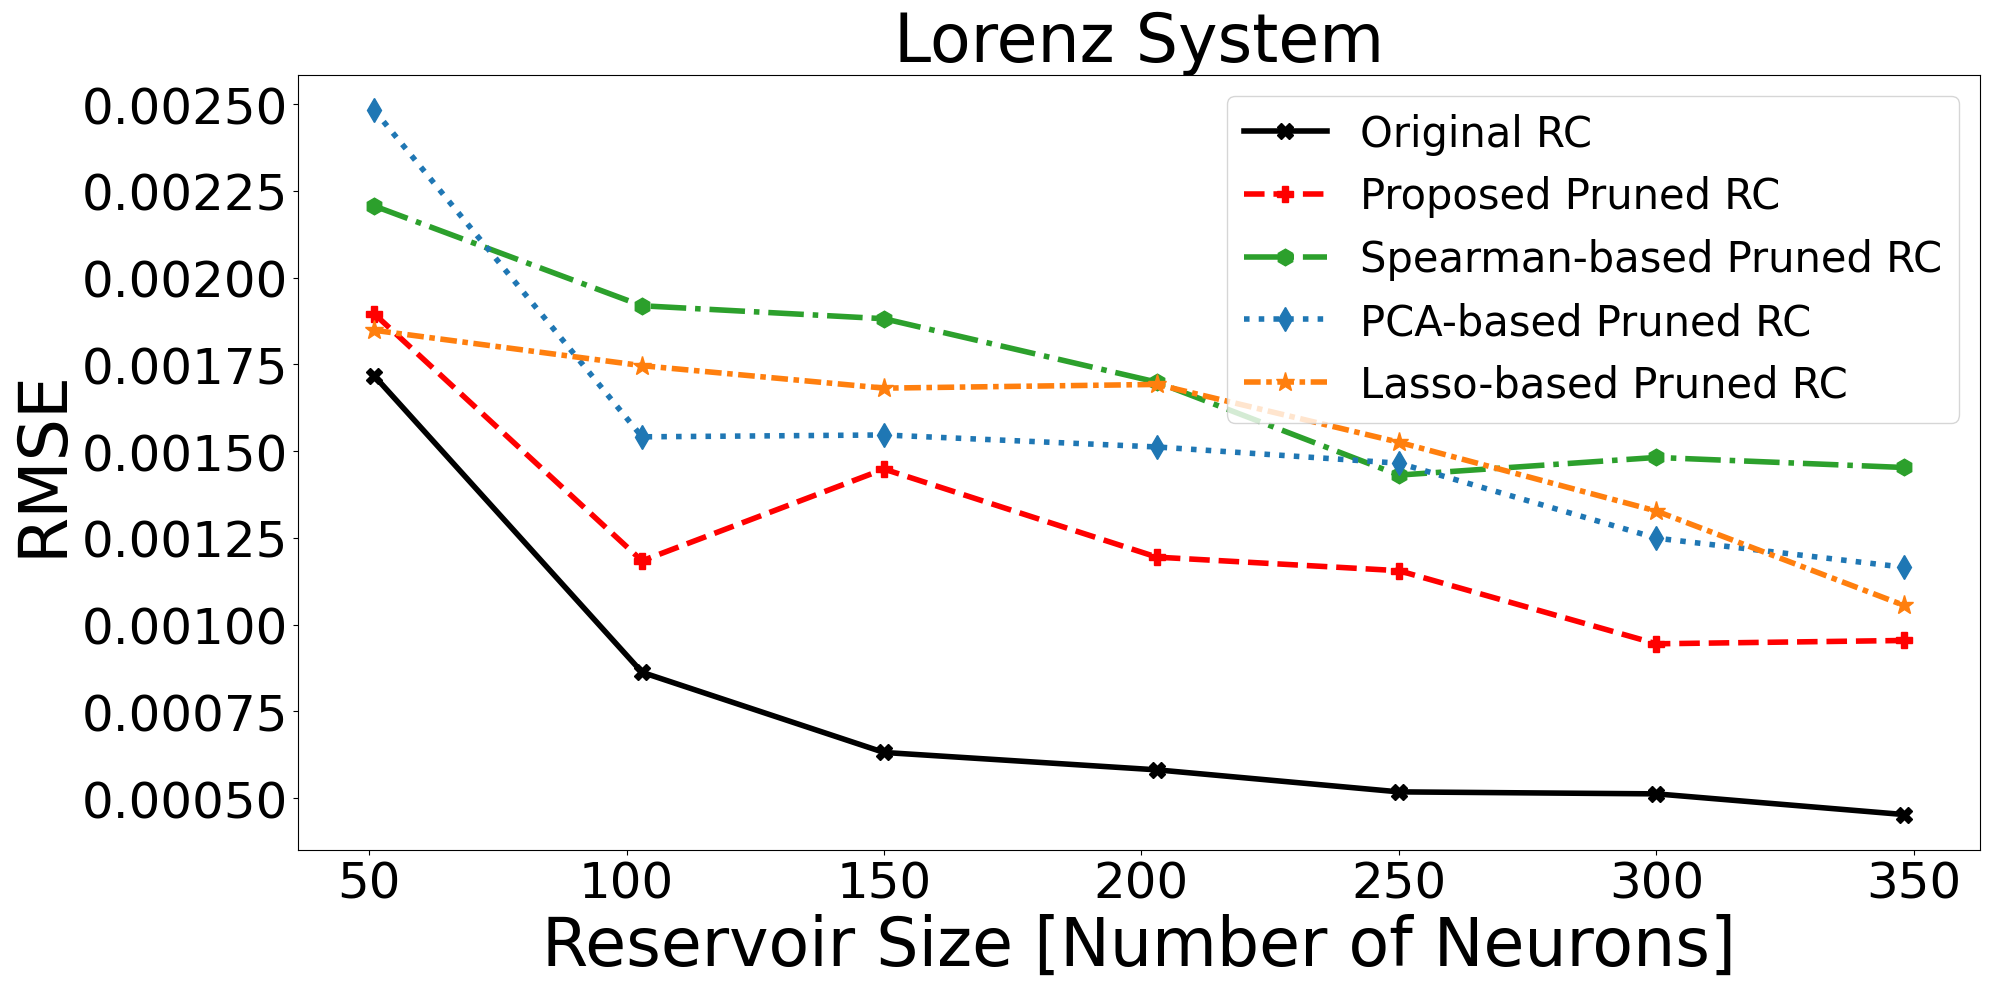

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (replace with actual results)
sizes = [result['N'] for result in results]
rmse_original_vals = [result['RMSE'] for result in results]
RMSE_HSIC_vals = [result['RMSE_HSIC'] for result in results]
RMSE_Spearman_vals = [result['RMSE_Spearman'] for result in results]
RMSE_PCA_vals = [result['RMSE_PCA'] for result in results]
RMSE_Lasso_vals = [result['RMSE_Lasso'] for result in results]

plt.figure(figsize=(20, 10))

# Updated color scheme with distinct styles and markers
plt.plot(sizes, rmse_original_vals, label='Original RC', linestyle='-', marker='X', color='black', linewidth=4, markersize=12)  # Black solid line with X marker
plt.plot(sizes, RMSE_HSIC_vals, label='Proposed Pruned RC', linestyle='--', marker='P', color='red', linewidth=4, markersize=12)  # Red dashed line with P marker
plt.plot(sizes, RMSE_Spearman_vals, label='Spearman-based Pruned RC', linestyle='-.', marker='h', color='#2ca02c', linewidth=4, markersize=12)  # Green dash-dot with hexagon marker
plt.plot(sizes, RMSE_PCA_vals, label='PCA-based Pruned RC', linestyle=':', marker='d', color='#1f77b4', linewidth=4, markersize=12)  # Blue dotted line with diamond marker
plt.plot(sizes, RMSE_Lasso_vals, label='Lasso-based Pruned RC', linestyle=(0, (3, 1, 1, 1)), marker='*', color='#ff7f0e', linewidth=4, markersize=14)  # Orange custom dashed with star marker

# Labels and title
plt.xlabel('Reservoir Size [Number of Neurons]', fontsize=48)
plt.ylabel('RMSE', fontsize=48)
plt.title('Lorenz System', fontsize=48)

# Legend and grid
plt.legend(fontsize=30, loc='upper right')
# plt.grid(True, linestyle='--', linewidth=1.9, alpha=0.6, color='gray')  # Applied grid with custom styling

# Tick settings
plt.xticks(fontsize=36)
plt.yticks(fontsize=36)

# Adjust x-axis ticks for better readability
# plt.xticks(np.arange(min(sizes), max(sizes)+1, 50))
import webbrowser
webbrowser.open("Lorenz.pdf") 
# Save plot
plt.tight_layout()
plt.savefig("Lorenz.pdf", bbox_inches='tight')
plt.savefig("Lorenz.pdf", bbox_inches='tight')

plt.show()







In [37]:
# reservoir_random = Reservoir(len(ind), lr=0.9, sr=0.8, input_connectivity=0.9,rc_connectivity=0.1,input_scaling=1)

# readout_random = Ridge(ridge=1e-2)
# esn_model_random = reservoir_random >> readout_random

# esn_model_random = esn_model_random.fit(X_train, Y_train, warmup=1000)
#  #states of each time stamp over test set
# reservoir_states_test_random = reservoir_random.run(X_test)  # Shape: (time_steps, num_neurons).
# reservoir_states_test_random.shape
# np.save('reservoir_states_test_random', reservoir_states_test_random)
# output_test_random = readout_random.run(reservoir_states_test_random)  # Shape: (time_steps, output_dim)
# output_test_random.shape
# np.save('output_test_random', output_test_random)
# print("RMSE:", rmse(output_test_random, Y_test), "R^2 score:", rsquare(output_test_random, Y_test))
# mae1 = mean_absolute_error(output_test_random, Y_test)
# print(f"Mean Absolute Error (MAE): {mae1}")

# **/////////////////////////////////////Quantization**

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from brevitas.nn import QuantHardTanh, QuantIdentity, QuantLinear
from brevitas.quant import Int8ActPerTensorFloat, Int8WeightPerTensorFloat
from reservoirpy.datasets import mackey_glass
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import rmse, rsquare
from reservoirpy import Node
import reservoirpy as rpy
rpy.verbosity(0)
rpy.set_seed(42)
pruned_res_size = len(ind)

# Parameters
N = pruned_res_size #reservoir size
bit_width = 8 # quantization bit width
#integer, out , scale,  quantizer, layer , ...
# input

from brevitas.nn import QuantIdentity
import math
def extract_Qinput(input, num_bits=8):
  quant_identity = QuantIdentity(return_quant_tensor=True,bit_width=num_bits)
  float_input = torch.tensor(input,dtype=torch.float64)
  quant_input = quant_identity(float_input)
  out = quant_input.int().detach().numpy()

  scale = quant_input.scale.detach().numpy()
  zero_point = quant_input.zero_point.numpy()
  print(f"Input int quantized:\n {out} \n")
  print(f"Input scale: {scale}")
  print(f"Input zero_point: {zero_point}")
  return out, scale, zero_point
from brevitas.nn import QuantLinear
from brevitas.quant import Int8ActPerTensorFloat,Int8WeightPerTensorFloat
import math


def quantize_output_layer(weights, num_bits=8):
  quant_linear = QuantLinear(2, 4,weight_bit_width=num_bits, weight_quant=Int8WeightPerTensorFloat, requires_grad=False)
  quant_linear.weight.data = torch.tensor(weights,dtype=torch.float64)

  out = quant_linear.quant_weight().int().detach().numpy()
  scale = quant_linear.quant_weight().scale.detach().numpy()
  # out = quant_linear.quant_weight().value.data.numpy()


  #out = out * 0

  return out,scale

int_x,x_scale,x_zero_point = extract_Qinput(X,num_bits=bit_width)
np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
print('Extract quantized integer Win and Scale and Zero_point')
int_Win,scale_Win,zero_point_Win = extract_Qinput(esn_model_pruned.nodes[0].Win.todense(),num_bits=bit_width)
print('Extract quantized integer Wr and Scale and Zero_point')
int_Wr,scale_Wr,zero_point_Wr = extract_Qinput(esn_model_pruned.nodes[0].W.todense(),num_bits=bit_width)
int_bias, scale_bias, zero_point_bias = extract_Qinput(esn_model_pruned.nodes[0].bias.todense(), num_bits=bit_width)


input_scale = (scale_Win * x_scale)
threshold_scale = 0.0078125
reservoir_scale = (scale_Wr * threshold_scale)

def compute_integer_thresholds(scale):

    a = -1  # Lower bound of Hard Tanh
    b = 1   # Upper bound of Hard Tanh
    a_scaled = np.int32(a / scale)
    b_scaled = np.int32(b / scale)
    return a_scaled, b_scaled

def piecewise_linear_hard_tanh_integer(x, a_scaled, b_scaled):

    # Apply saturation logic
    x = np.where(x < a_scaled, a_scaled, x)
    x = np.where(x > b_scaled, b_scaled, x)
    x=x + b_scaled
    return (x / 256).astype(np.int32)

a_scaled, b_scaled = compute_integer_thresholds(input_scale)
c_scaled, d_scaled = compute_integer_thresholds(reservoir_scale)

from reservoirpy import Node
def forward2(node: Node, x: np.ndarray) -> np.ndarray:
    state = node.state()  # get current node state  # Current reservoir state as integer
    state_int = state.astype(np.int64)
    W_res = node.Wr
    W_in = node.Win
    bias_res = node.Bias
    state_int = state_int.reshape(1,N)

    r = state_int @ W_res.astype(np.int32)
    s = x @ W_in.astype(np.int32).T
    s = s.reshape(1,N)
    # Precompute thresholds and scale
    # a_scaled, b_scaled = compute_integer_thresholds(scale_Wr)
    bias_res = bias_res.reshape(1, N)



    # Apply integer PLA to reservoir and input contributions
    out_r = piecewise_linear_hard_tanh_integer(s,a_scaled, b_scaled)
    out_s = piecewise_linear_hard_tanh_integer(r,c_scaled, d_scaled)

    return out_r + out_s + bias_res

def initialize(node: Node, x: np.ndarray = None, y: np.ndarray = None):
    """This function receives a data point x at runtime and uses it to
    infer input and output dimensions.
    """
    if x is not None:
        node.set_input_dim(x.shape[1])
        node.set_output_dim(N)
        node.set_param("Wr", int_Wr)
        node.set_param("Win", int_Win)
        node.set_param("Bias", int_bias)

class CustomNode(Node):
    def __init__(self, const2=-1, name=None):
        super().__init__(
            forward=forward2,
            initializer=initialize,

            params={"const1": None, "Wr":None, "Win":None, "Bias":None},
            hypers={"const2": const2},
            name=name,
        )

node = CustomNode(const2=-1, name="custom_node3")
# readout_pruned.ridge = 1e-8

esn_model_PTQ = node >> readout_pruned

Quantized_States = node.run(int_x[:5000].astype(np.float64))

Quantized_States = Quantized_States * threshold_scale
readout_pruned.fit(Quantized_States, X[1:5001].astype(np.float64), warmup=1000)

# esn_model_PTQ = node >> readout_pruned

# esn_model_PTQ = esn_model_PTQ.fit(int_x[:5000].astype(np.float64), int_x[1:5001].astype(np.float64), warmup=1000)

Quantized_States = node.run(int_x[5001:-1].astype(np.float64))
Quantized_States = Quantized_States * threshold_scale
Y_pred_PTQ = readout_pruned.run(Quantized_States)
min_pred = np.min(Y_pred_PTQ)
max_pred = np.max(Y_pred_PTQ)
Y_pred_PTQ_normalized = 2 * (Y_pred_PTQ - min_pred) / (max_pred - min_pred) - 1

# Wout_quantized, scale_out = quantize_output_layer(readout.Wout,num_bits=bit_width)
# readout.Wout = Wout_quantized

# a=threshold_scale * scale_out

# Y_pred_PTQ = esn_model_PTQ.run(int_x[5001:-1])
# Y_pred_PTQ = Y_pred_PTQ *a

from reservoirpy.observables import rmse, rsquare

print("RMSE PQ:", rmse(X[5002:], Y_pred_PTQ), "R^2 score:", rsquare(X[5002:], Y_pred_PTQ))

plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future.")
plt.xlabel("$t$")
plt.plot(X[-100:], label="Predicted sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ[-100:], label="Real sin(t+1)", color="red")
plt.legend()
plt.show()

min_x = np.min(X[-10:])
max_x = np.max(X[-10:])
min_pred = np.min(Y_pred_PTQ[-10:])
max_pred = np.max(Y_pred_PTQ[-10:])

Y_pred_PTQ_normalized = (Y_pred_PTQ[-10:] - min_pred) / (max_pred - min_pred) * (max_x - min_x) + min_x

print("RMSE PQ:", rmse(Y_pred_PTQ[-10:], Y_pred_PTQ_normalized), "R^2 score:", rsquare(Y_pred_PTQ[-10:], Y_pred_PTQ_normalized))

plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future (normalized).")
plt.xlabel("$t$")
plt.plot(X[-10:], label="Real sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ_normalized, label="Predicted sin(t+1)", color="red")
plt.legend()
plt.show()

NameError: name 'ind' is not defined